# Proxy Statistics

In [1]:
import os
import re
import json
import math
from common import *
from pathlib import Path
from collections import defaultdict
from data import RawDataFile
from experiment import Treatment, NetworkSetting
from treatments.picoquic import treatment_map as http_treatment_map, NETWORK_SETTING as http_network_setting
from treatments.media import treatment_map as media_treatment_map, NETWORK_SETTING as media_network_setting
from treatments.multicast import treatment_map as multicast_treatment_map

## Collect data

```
# Build the proxy with debug logging of cache statistics
cd $SIDEKICK_HOME/deps/
./build_deps.sh 8
```

In [2]:
# Make the data directory
http_data_home = f'{DATA_HOME}/proxy_statistics/http'
media_data_home = f'{DATA_HOME}/proxy_statistics/media'
multicast_data_home = f'{DATA_HOME}/proxy_statistics/multicast'
os.system(f'mkdir -p {http_data_home}')
os.system(f'mkdir -p {media_data_home}')
os.system(f'mkdir -p {multicast_data_home}')

0

In [24]:
# HTTP benchmark
loss4 = NetworkSetting(bw1=50, bw2=20, delay1=2, delay2=30, loss1=4, loss2=0)
loss16 = NetworkSetting(bw1=50, bw2=20, delay1=2, delay2=30, loss1=16, loss2=0)
def gen_http_cmd(label, time_s, network_setting=loss4):
    treatment = http_treatment_map(label)
    data_size = 125000 * 20 * time_s # 125000 * bottleneck_bw * time_s
    return RawDataFile(treatment, network_setting, '').cmd(data_size=data_size, num_trials=1, debug=True, logdir=f'{http_data_home}/{network_setting.label()}/{label}')

http_labels = [
    # 'picoquic_sidekick_30ms',
    # 'picoquic_sidekick_30ms_hint',
    # 'picoquic_iblt_30ms',
    'picoquic_iblt_30ms_hint',
    'picoquic_iblt_30ms_hint_cache48000',
    # 'picoquic_iblt_30ms_hint_cache16000',
    # 'picoquic_iblt_30ms_hint_reset',
    # 'picoquic_iblt_30ms_hint_cache48000_reset',
    # 'picoquic_iblt_30ms_hint_cache16000_reset',
]
for label in http_labels:
    print(gen_http_cmd(label, 15))

print()
# print(gen_http_cmd('picoquic_sidekick_30ms_hint', 10, network_setting=loss16))
# print(gen_http_cmd('picoquic_iblt_30ms_hint', 10, network_setting=loss16))
# print(gen_http_cmd('picoquic_sidekick_30ms', 10, network_setting=loss16))
# print(gen_http_cmd('picoquic_iblt_30ms', 10, network_setting=loss16))

sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 2 --delay2 30 --loss1 4 --loss2 0 -t 1 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/http/network_50_20_2_30_None_None_4_0/picoquic_iblt_30ms_hint --label picoquic_iblt_30ms_hint --proxy sidekick --freq-pkts 16 --freq-ms 10 --threshold 160 --riblt --quack-hint --network-statistics picoquic --client-quacker --ack-delay 30 -n 37500000
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 2 --delay2 30 --loss1 4 --loss2 0 -t 1 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/http/network_50_20_2_30_None_None_4_0/picoquic_iblt_30ms_hint_cache48000 --label picoquic_iblt_30ms_hint_cache48000 --proxy sidekick --freq-pkts 16 --freq-ms 10 --threshold 160 --riblt --quack-hint --cache-capacity 48000 --network-statistics picoquic --client-quacker --ack-delay 30 -n 37500000



In [4]:
##### Media benchmark
def gen_media_cmd(label, time_s, network_setting=media_network_setting):
    treatment = media_treatment_map(label)
    return RawDataFile(treatment, network_setting, '').cmd(duration=time_s, debug=True, logdir=f'{media_data_home}/{label}')

media_labels = [
    'iblt_delay110_hint_nack',
    'iblt_delay110_hint_nack_cache4000',
    'iblt_delay110_hint_nack_cache10000',
]
for label in media_labels:
    print(gen_media_cmd(label, 15))

sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 50 --delay2 100 --loss1 10 --loss2 0 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/media/iblt_delay110_hint_nack --label iblt_delay110_hint_nack --proxy sidekick --freq-ms 0 --threshold 40 --riblt --quack-hint --quack-nack --freq-pkts 0 --network-statistics media --client-quacker --ack-delay 110 --duration 15
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 50 --delay2 100 --loss1 10 --loss2 0 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/media/iblt_delay110_hint_nack_cache4000 --label iblt_delay110_hint_nack_cache4000 --proxy sidekick --freq-ms 0 --threshold 40 --riblt --quack-hint --quack-nack --freq-pkts 0 --cache-capacity 4000 --network-statistics media --client-quacker --ack-delay 110 --duration 15
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 50 --delay2 100 --loss1 10 --loss2 0 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statis

In [5]:
# Multicast benchmark
def gen_multicast_cmd(label, time_s, num_clients):
    treatment = multicast_treatment_map[label]
    network_setting = NetworkSetting(bw1=20, bw2=50, delay1=30, delay2=10, loss1=0, loss2=10)
    return RawDataFile(treatment, network_setting, '').cmd(duration=time_s, debug=True, logdir=f'{multicast_data_home}/{num_clients}/{label}', num_clients=num_clients, client_quacker=num_clients)

multicast_labels = [
    # 'psum_delay30',
    # 'psum_delay30_hint_nack',
    'iblt_delay30',
    'iblt_delay30_hint_nack',
]
num_clients = [
    # 1,
    16,
]
for n in num_clients:
    for label in multicast_labels:
        print(gen_multicast_cmd(label, 15, n))

sudo -E python3 emulation/main.py --bw1 20 --bw2 50 --delay1 30 --delay2 10 --loss1 0 --loss2 10 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/multicast/16/iblt_delay30 --label iblt_delay30 --proxy sidekick-multicast --freq-ms 0 --threshold 40 --riblt --freq-pkts 2 --network-statistics multicast --ack-delay 30 --duration 15 --num-clients 16 --client-quacker 16
sudo -E python3 emulation/main.py --bw1 20 --bw2 50 --delay1 30 --delay2 10 --loss1 0 --loss2 10 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/multicast/16/iblt_delay30_hint_nack --label iblt_delay30_hint_nack --proxy sidekick-multicast --freq-ms 0 --threshold 40 --riblt --quack-hint --quack-nack --freq-pkts 0 --network-statistics multicast --ack-delay 30 --duration 15 --num-clients 16 --client-quacker 16


## Decode statistics

In [10]:
def parse_decode_statistics(data_home, label, normalize=True):
    # Read the raw data file
    filename = f'{data_home}/{label}/router.log'
    if not Path(filename).is_file():
        print('MISSING:', filename)
        return
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Parse the number of missing elements in each decoded quACK
    data = defaultdict(lambda: 0)
    errors = defaultdict(lambda: 0)
    reset = False
    for line in lines:
        match1 = re.search(r'quack (\d+) cache_len=(\d+).*last_index=(\d+) missing=(\[[\d, ]+\]),', line)
        if match1:
            _count = int(match1.group(1))
            _cache_len = int(match1.group(2))
            _last_index = int(match1.group(3))
            missing = json.loads(match1.group(4))
            data[len(missing)] += 1
            continue
        if 'Sending reset packet' in line:
            reset = True
            continue
        if reset:
            match2 = re.search(r'Failed to decode quACK: (\w+) ', line)
            if match2:
                errors[match2.group(1)] += 1
                reset = False
            elif 'Reset due to exceeding cache capacity' in line:
                errors['ExceededCacheCapacity'] += 1
                reset = False

    # Possibly normalize data
    total = sum(data.values())
    print(label, total, dict(errors))
    if normalize:
        for key in data.keys():
            data[key] /= total
    return data

In [11]:
def format_decode_statistics_data(network_setting, http_labels, media_labels, multicast_labels, num_clients):
    data = {}
    for http_label in http_labels:
        data[http_label] = parse_decode_statistics(f'{http_data_home}/{network_setting.label()}', http_label)
    for media_label in media_labels:
        data[media_label] = parse_decode_statistics(media_data_home, media_label)
    for multicast_label in multicast_labels:
        data[multicast_label] = parse_decode_statistics(f'{multicast_data_home}/{num_clients}', multicast_label)
    return dict(filter(lambda item: item[1] is not None, data.items()))

In [12]:
def plot_decode_statistics(network_setting=loss4, ncol=3, http_labels=[], media_labels=[], multicast_labels=[], num_clients=16, pdf=None, title=None, overlay=True):
    # Parse data and keys as full x range across all dictionaries
    all_data = format_decode_statistics_data(network_setting, http_labels, media_labels, multicast_labels, num_clients)
    labels = list(filter(lambda label: label in all_data, http_labels + media_labels + multicast_labels))
    keys = set()
    for data in all_data.values():
        keys |= set(data.keys())
    keys = np.array(sorted(keys))
    
    # Plot bars either as a multi-bar graph or overlay graph
    plt.figure(figsize=(6, 3))
    bar_width = 1.0 / (len(labels) + 1)
    for i, label in enumerate(labels):
        data = all_data[label]
        plot_data = [data.get(k, 0) for k in keys]
        if overlay:
            plt.bar(keys, plot_data, width=1, alpha=0.6, label=label)
        else:
            plt.bar(keys + i * bar_width, plot_data, width=bar_width, label=label)

    # Format axes
    plt.xlabel('Num Missing in QuACK Decodes')
    plt.ylabel('Proportion')
    plt.ylim(0, 1)
    plt.xticks(keys)

    # Plot legend and title above
    plot_title_and_legend(title, labels, base_height=1.15, row_height=0.1, title_height=0.12, ncol=ncol)

    # Save the PDF
    if pdf:
        save_pdf(pdf)
    plt.show()

psum_delay0 19 {}
psum_delay45 21 {}
psum_delay90 22 {}
psum_delay45_hint 29 {}
psum_delay45_nack 20 {}
psum_delay45_hint_nack 19 {}
iblt_delay0 18 {}
iblt_delay45 20 {}
iblt_delay90 20 {}
iblt_delay45_hint 15 {}
iblt_delay45_nack 20 {}
iblt_delay45_hint_nack 19 {}
iblt_delay45_hint_nack_cache2000 23 {'MissingLastValue': 1}
iblt_delay45_hint_nack_cache10000 23 {}
psum_delay45_hint_nack_cache10000 28 {}


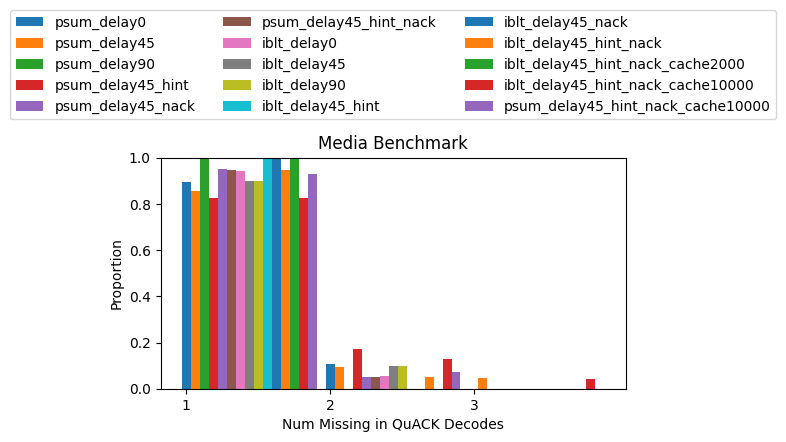

In [14]:
plot_decode_statistics(media_labels=media_labels, overlay=False, title='Media Benchmark')

psum_delay45 19 {'NotASubset': 1}
psum_delay45_hint_nack 28 {}


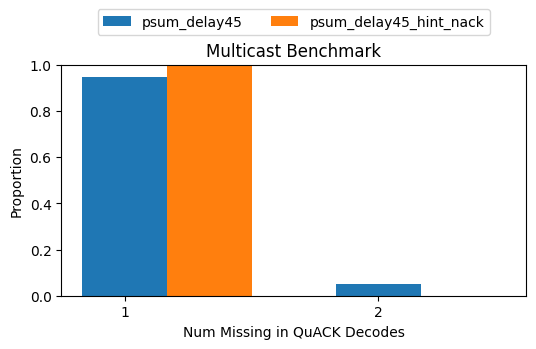

In [21]:
plot_decode_statistics(multicast_labels=multicast_labels, num_clients=1, overlay=False, title='Multicast Benchmark')

## Cache statistics

In [6]:
def parse_cache_statistics(data_home, label, pkts=False):
    # Read the raw data file
    filename = f'{data_home}/{label}/router.log'
    if not Path(filename).is_file():
        print('MISSING:', filename)
        return
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Parse the raw data
    xs = [] # time, in secs
    ys = [] # cache size, in bytes
    for line in lines:
        match = re.search(r'cache_statistics Instant { tv_sec: (\d+), tv_nsec: (\d+) } (\w+) nbytes=(\d+) len=(\d+)', line)
        if not match:
            continue
        tv_sec = int(match.group(1))
        tv_nsec = int(match.group(2))
        event = match.group(3)
        nbytes = int(match.group(4))
        npkts = int(match.group(5))
        xs.append(tv_sec + tv_nsec / 1000000000.0)
        if pkts:
            ys.append(npkts)
        else:
            ys.append(nbytes / 1000.0) # bytes to kB

    # Normalize data
    print(label, len(xs))
    xmin = xs[0]
    xs = [x - xmin for x in xs]
    return { 'xs': xs, 'ys': ys }

In [7]:
def parse_virtual_insertions(data_home, label, pkts=None):
    # Read the raw data file
    filename = f'{data_home}/{label}/router.log'
    if not Path(filename).is_file():
        print('MISSING:', filename)
        return
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Map from the sidekick connection ID to the number of insertions
    insertion_map = defaultdict(lambda: 0)

    # Parse the raw data
    xs = [] # time, in secs
    ys = [] # bytes used for virtual buffers, in bytes 4*num_conns + 8*num_insertions
    for line in lines:
        match = re.search(r'cache_statistics Instant { tv_sec: (\d+), tv_nsec: (\d+) } virtual_insertions conn=(\w+) len=(\d+)', line)
        if not match:
            continue
        tv_sec = int(match.group(1))
        tv_nsec = int(match.group(2))
        conn = match.group(3)
        num_insertions = int(match.group(4))
        xs.append(tv_sec + tv_nsec / 1000000000.0)
        insertion_map[conn] = num_insertions
        nbytes = 4 * len(insertion_map.keys()) + 8 * sum(insertion_map.values())
        ys.append(nbytes / 1000.0) # bytes to kB

    # Normalize data
    print(label, len(xs))
    xmin = xs[0]
    xs = [x - xmin for x in xs]
    return { 'xs': xs, 'ys': ys }

In [8]:
def format_cache_statistics_data(network_setting, http_labels, media_labels, multicast_labels, num_clients, insertions=False, pkts=False):
    data = {}
    func = parse_virtual_insertions if insertions else parse_cache_statistics
    for http_label in http_labels:
        data[http_label] = func(f'{http_data_home}/{network_setting.label()}', http_label, pkts=pkts)
    for media_label in media_labels:
        data[media_label] = func(media_data_home, media_label, pkts=pkts)
    for multicast_label in multicast_labels:
        data[multicast_label] = func(f'{multicast_data_home}/{num_clients}', multicast_label, pkts=pkts)
    return dict(filter(lambda item: item[1] is not None, data.items()))

In [62]:
def plot_cache_statistics(http_labels=[], media_labels=[], multicast_labels=[], figure_labels=None, styles=None, network_setting=loss4, num_clients=16, insertions=False, pkts=False, title=None, xlim=0, ylim=0, pdf=None):
    # Parse data and keys as full x range across all dictionaries
    all_data = format_cache_statistics_data(network_setting, http_labels, media_labels, multicast_labels, insertions=insertions, num_clients=num_clients, pkts=pkts)
    labels = list(filter(lambda label: label in all_data, http_labels + media_labels + multicast_labels))
    
    # Plot each treatment
    plt.figure(figsize=(6, 2))
    for i, label in enumerate(labels):
        data = all_data[label]
        if figure_labels and styles:
            style = styles[i]
            title = None
            plt.step(data['xs'], data['ys'], where='post', label=figure_labels[i], color=style.color)
        else:
            plt.step(data['xs'], data['ys'], where='post', label=label)
        print(label, 'average =', sum(data['ys'])/len(data['ys']))

    # Format axes
    plt.xlabel('Time (s)', labelpad=-10)
    if insertions:
        plt.ylabel('Virtual Cache Usage (KB)')
    elif pkts:
        plt.ylabel('Packet Cache Usage (Packets)')
    else:
        plt.ylabel('Packet Cache Usage (KB)')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    
    # Plot legend and title above
    plot_title_and_legend(title, labels, ncol=2, base_height=1.25, row_height=0.1, title_height=0.12)

    # Save the PDF
    if pdf:
        save_pdf(pdf)
    plt.show()

## Main benchmarks

picoquic_iblt_30ms_hint 29479
picoquic_iblt_30ms_hint_cache48000 29474
picoquic_iblt_30ms_hint average = 22.057439329692322
picoquic_iblt_30ms_hint_cache48000 average = 21.931292223654747
../figures/cache_http.pdf


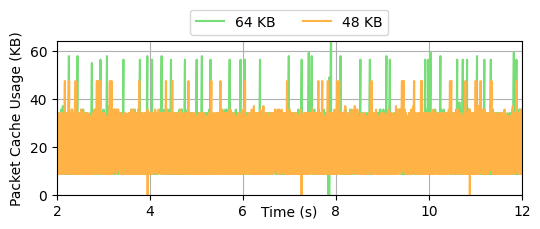

In [63]:
figure_labels = ['64 KB', '48 KB']
styles = [STYLE['Split Connection'], STYLE['Packrat']]
plot_cache_statistics(http_labels=[
    'picoquic_iblt_30ms_hint',
    'picoquic_iblt_30ms_hint_cache48000',
], xlim=(2, 12), ylim=(0,64), title='HTTP Benchmark', pdf='../figures/cache_http.pdf', figure_labels=figure_labels, styles=styles)

iblt_delay110_hint_nack 1018
iblt_delay110_hint_nack_cache4000 1072
iblt_delay110_hint_nack average = 3.790379174852652
iblt_delay110_hint_nack_cache4000 average = 2.3675373134328357
../figures/cache_media.pdf


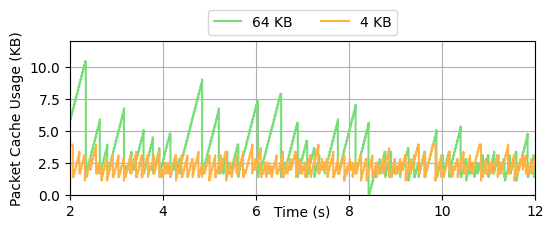

In [64]:
figure_labels = ['64 KB', '4 KB']
styles = [STYLE['Split Connection'], STYLE['Packrat']]
plot_cache_statistics(media_labels=[
    'iblt_delay110_hint_nack',
    'iblt_delay110_hint_nack_cache4000',
    # 'iblt_delay110_hint_nack_cache10000',
], xlim=(2, 12), ylim=(0,12), title='Media Benchmark', pdf='../figures/cache_media.pdf', figure_labels=figure_labels, styles=styles)

iblt_delay30 5999
iblt_delay30_hint_nack 1144
iblt_delay30 average = 0.0780523420570095
iblt_delay30_hint_nack average = 0.17788111888111888
../figures/cache_multicast.pdf


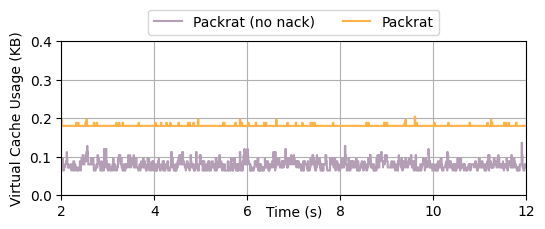

In [65]:
labels = [
    'iblt_delay30',
    'iblt_delay30_hint_nack',
]
xlim = (2, 12)

figure_labels = ['Packrat (no nack)', 'Packrat']
styles = [STYLE[label] for label in figure_labels]

# plot_cache_statistics(multicast_labels=labels, xlim=xlim, ylim=(0,80), num_clients=1, title='Multicast Benchmark (num_clients=1)')
# plot_cache_statistics(multicast_labels=labels, xlim=xlim, ylim=(0,0.4), num_clients=1, insertions=True, title='Multicast Benchmark (num_clients=1)')
# plot_cache_statistics(multicast_labels=labels, xlim=xlim, ylim=(0,80), num_clients=16, title='Multicast Benchmark (num_clients=16)')
plot_cache_statistics(multicast_labels=labels, xlim=xlim, ylim=(0,0.4), num_clients=16, insertions=True, pdf='../figures/cache_multicast.pdf', figure_labels=figure_labels, styles=styles) # 200kB/16 = 12500